<a href="https://colab.research.google.com/github/pollybond/MD-Data-Science/blob/master/%D0%9F%D1%80%D0%B5%D0%B4%D0%B8%D0%BA%D1%82%D0%B8%D0%B2%D0%BD%D0%B0%D1%8F_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D1%82%D0%B8%D0%BA%D0%B0_%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D0%B2%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D1%85_%D1%80%D1%8F%D0%B4%D0%BE%D0%B2_%D0%B8_%D0%B8%D1%85_%D0%BF%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from pathlib import Path
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
import lightgbm as lgb
from sktime.classification.kernel_based import RocketClassifier
from tqdm import tqdm
import pyarrow.parquet as pq

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_theme(style="whitegrid", font="sans-serif")

In [1]:
!pip install -q sktime lightgbm statsmodels shap tqdm pyarrow seaborn plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 7.8 MB/s eta 0:00:00


**Просмотр данных**

In [3]:
FILE_PATH = "data/Благовещенск_2022-01-01_2022-12-31.parquet"

meta = pq.read_metadata(FILE_PATH)
schema = pq.read_schema(FILE_PATH)

df = pd.read_parquet(FILE_PATH)
display(df.head())
display(df.tail())
df.info()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
time,,,,,,,,
2022-01-01 00:00:00,-26.200001,67,0.0,0.0,0.0,0,5.7,1014.599976
2022-01-01 01:00:00,-26.299999,67,0.0,0.0,0.0,0,4.5,1014.200012
2022-01-01 02:00:00,-26.500000,68,0.0,0.0,0.0,0,2.8,1014.200012
2022-01-01 03:00:00,-26.700001,70,0.0,0.0,0.0,0,1.0,1013.599976
2022-01-01 04:00:00,-27.000000,71,0.0,0.0,0.0,0,3.8,1013.400024


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
time,,,,,,,,
2022-12-31 19:00:00,-18.400000,67,0.0,0.0,0.0,0,10.7,1004.400024
2022-12-31 20:00:00,-19.100000,68,0.0,0.0,0.0,0,10.0,1004.400024
2022-12-31 21:00:00,-21.000000,73,0.0,0.0,0.0,0,11.8,1003.799988
2022-12-31 22:00:00,-22.000000,74,0.0,0.0,0.0,0,11.5,1004.200012
2022-12-31 23:00:00,-22.299999,73,0.0,0.0,0.0,0,10.9,1004.200012


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8760 entries, 2022-01-01 00:00:00 to 2022-12-31 23:00:00
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature_2m        8760 non-null   float32
 1   relative_humidity_2m  8760 non-null   int64  
 2   precipitation         8760 non-null   float32
 3   rain                  8760 non-null   float32
 4   snowfall              8760 non-null   float32
 5   weathercode           8760 non-null   int64  
 6   wind_speed_10m        8760 non-null   float32
 7   surface_pressure      8760 non-null   float32
dtypes: float32(6), int64(2)
memory usage: 410.6 KB


**Загрузка данных**

In [4]:
CLIMATE_MAP = {
    "Москва": "Умеренно-континентальный", "Санкт-Петербург": "Умеренно-континентальный",
    "Сочи": "Субтропический", "Геленджик": "Субтропический",
    "Благовещенск": "Муссонный", "Находка": "Муссонный"
}
DATA_DIR = Path("data")

REQUIRED_COLS = [
    "temperature_2m", "relative_humidity_2m", "precipitation",
    "rain", "snowfall", "weathercode", "wind_speed_10m", "surface_pressure"
]

def load_data():
    files = sorted(DATA_DIR.glob("*.parquet"))
    if not files:
        raise FileNotFoundError("Файлы .parquet не найдены в папке data/")

    dfs = []
    for f in files:
        city = f.stem.split("_")[0]
        if city not in CLIMATE_MAP:
            continue

        df = pd.read_parquet(f)

        # Обработка индекса: если это не DatetimeIndex — пробуем распарсить
        if not pd.api.types.is_datetime64_any_dtype(df.index):
            # Ищем колонку с датой среди данных
            date_col = next((c for c in df.columns if c.lower() in ['time', 'date', 'datetime']), None)
            if date_col:
                df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
                df.set_index(date_col, inplace=True)
            else:
                # Fallback: генерация из имени файла
                import re
                match = re.search(r'(\d{4}-\d{2}-\d{2})', f.name)
                if match:
                    df.index = pd.date_range(start=match.group(1), periods=len(df), freq='h')

        # Приводим индекс к единому имени
        df.index.name = 'date'

        # Фильтр по годам
        df = df[(df.index.year >= 2019) & (df.index.year <= 2025)]
        if len(df) == 0:
            continue

        # Проверка и восстановление колонок
        for req in REQUIRED_COLS:
            if req not in df.columns:
                key = req.split('_')[0]
                candidates = [c for c in df.columns if key in c.lower()]
                if candidates:
                    df.rename(columns={candidates[0]: req}, inplace=True)
                else:
                    df[req] = np.nan

        df["city"] = city
        df["climate"] = CLIMATE_MAP[city]

        # Приведение типов
        for col in REQUIRED_COLS:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        dfs.append(df)
        print(f"{city} ({f.stem.split('_')[1]}): {len(df)} строк, индекс: {df.index.dtype}")

    if not dfs:
        raise ValueError("Не удалось загрузить данные.")

    result = pd.concat(dfs).sort_index()
    print(f"\nИтого: {len(result)} строк, городов: {result['city'].nunique()}")
    print(f"Индекс: {result.index.dtype}, диапазон: {result.index.min()} — {result.index.max()}")
    print(f"Колонки: {list(result.columns)}")
    return result, sorted(result["city"].unique())

df, CITIES = load_data()

Благовещенск (2019-01-01): 8760 строк, индекс: datetime64[ns]
Благовещенск (2020-01-01): 8784 строк, индекс: datetime64[ns]
Благовещенск (2021-01-01): 8760 строк, индекс: datetime64[ns]
Благовещенск (2022-01-01): 8760 строк, индекс: datetime64[ns]
Благовещенск (2023-01-01): 8760 строк, индекс: datetime64[ns]
Благовещенск (2024-01-01): 8784 строк, индекс: datetime64[ns]
Благовещенск (2025-01-01): 8760 строк, индекс: datetime64[ns]
Геленджик (2019-01-01): 8760 строк, индекс: datetime64[ns]
Геленджик (2020-01-01): 8784 строк, индекс: datetime64[ns]
Геленджик (2021-01-01): 8760 строк, индекс: datetime64[ns]
Геленджик (2022-01-01): 8760 строк, индекс: datetime64[ns]
Геленджик (2023-01-01): 8760 строк, индекс: datetime64[ns]
Геленджик (2024-01-01): 8784 строк, индекс: datetime64[ns]
Геленджик (2025-01-01): 8760 строк, индекс: datetime64[ns]
Москва (2019-01-01): 8760 строк, индекс: datetime64[ns]
Москва (2020-01-01): 8784 строк, индекс: datetime64[ns]
Москва (2021-01-01): 8760 строк, индекс: 

**Ресемплинг к суточным данным + обработка пропусков**

In [5]:
def safe_resample(df):
    """
    Ресемплинг почасовых данных к суточным.
    - Температура, влажность, давление, ветер -> mean
    - Осадки, снег -> sum (накопительные величины)
    - Погодный код -> first (первое значение дня)
    """
    agg_rules = {
        **{c: "mean" for c in ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "surface_pressure"]},
        **{c: "sum" for c in ["precipitation", "rain", "snowfall"]},
        "weathercode": "first",
        "city": "first",
        "climate": "first"
    }
    return df.resample("D").agg(agg_rules)

df_daily = safe_resample(df)

# Интерполяция пропусков (линейная, не более 2 дней подряд)
df_daily[REQUIRED_COLS] = df_daily[REQUIRED_COLS].interpolate(method="linear", limit=2)
df_daily[REQUIRED_COLS] = df_daily[REQUIRED_COLS].ffill()
df_daily.dropna(subset=REQUIRED_COLS, inplace=True)

print(f"После обработки: {df_daily.shape[0]} дней × {df_daily.shape[1]} колонок")

После обработки: 2557 дней × 10 колонок


**EDA**

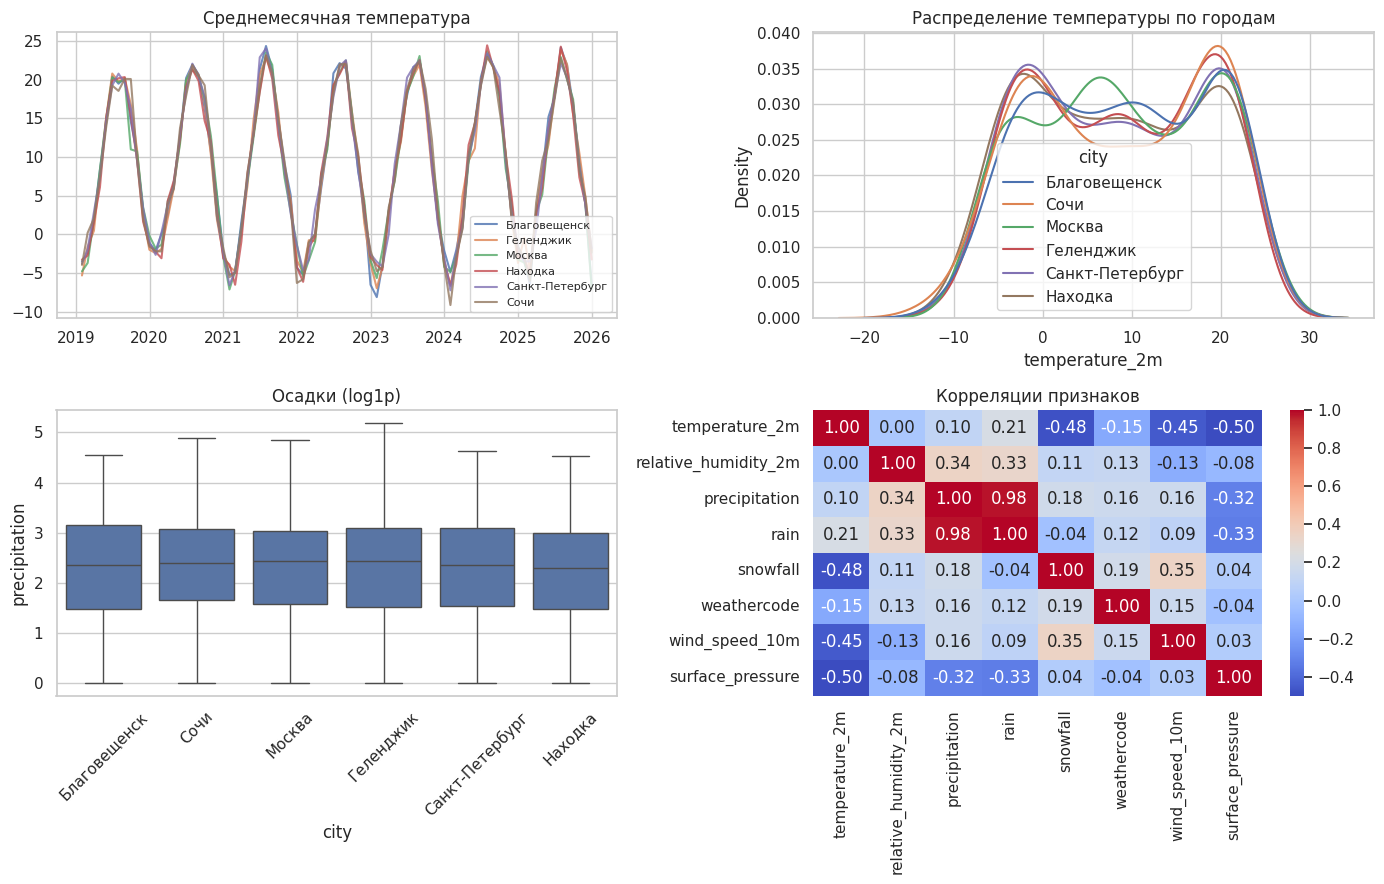


Тест Дики-Фуллера (стационарность температуры):
Благовещенск       | ADF=-6.524, p=0.0000 | Стационарный
Геленджик          | ADF=-8.312, p=0.0000 | Стационарный
Москва             | ADF=-8.845, p=0.0000 | Стационарный
Находка            | ADF=-8.122, p=0.0000 | Стационарный
Санкт-Петербург    | ADF=-7.929, p=0.0000 | Стационарный
Сочи               | ADF=-7.602, p=0.0000 | Стационарный


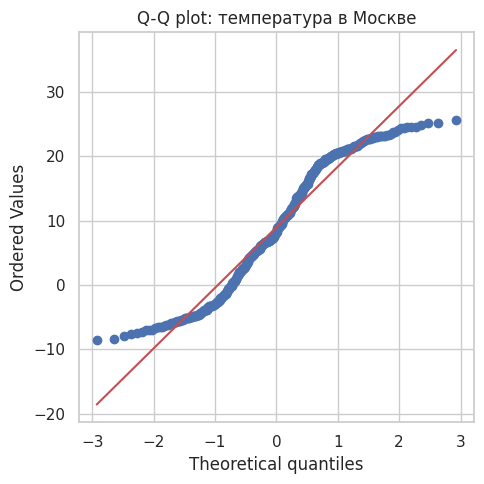

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Среднемесячная температура по городам
for city in CITIES:
    s = df_daily.loc[df_daily["city"] == city, "temperature_2m"]
    if len(s) > 10:
        axes[0, 0].plot(s.resample("M").mean(), label=city, alpha=0.8)
axes[0, 0].set_title("Среднемесячная температура"); axes[0, 0].legend(fontsize=8)

# Распределение температуры
sns.kdeplot(data=df_daily, x="temperature_2m", hue="city", ax=axes[0, 1], common_norm=False)
axes[0, 1].set_title("Распределение температуры по городам")

# Осадки (log-масштаб)
sns.boxplot(data=df_daily, x="city", y=np.log1p(df_daily["precipitation"]), ax=axes[1, 0])
axes[1, 0].set_title("Осадки (log1p)"); axes[1, 0].tick_params(axis='x', rotation=45)

# Корреляционная матрица
corr = df_daily[REQUIRED_COLS].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1, 1], fmt=".2f")
axes[1, 1].set_title("Корреляции признаков")

plt.tight_layout(); plt.show()

# Тест Дики-Фуллера на стационарность
print("\nТест Дики-Фуллера (стационарность температуры):")
for city in CITIES:
    series = df_daily.loc[df_daily["city"] == city, "temperature_2m"].dropna()
    if len(series) < 30 or series.nunique() < 5:
        print(f"{city:18} | Недостаточно данных")
        continue
    res = adfuller(series)
    status = "Стационарный" if res[1] < 0.05 else "Нестационарный"
    print(f"{city:18} | ADF={res[0]:.3f}, p={res[1]:.4f} | {status}")

# Q-Q plot для проверки нормальности (на примере Москвы)
from scipy import stats as sp_stats
city_sample = df_daily[df_daily["city"] == "Москва"]["temperature_2m"].dropna()
plt.figure(figsize=(5, 5))
sp_stats.probplot(city_sample, dist="norm", plot=plt)
plt.title("Q-Q plot: температура в Москве"); plt.tight_layout(); plt.show()

**Инжениринг признаков**

In [7]:
def engineer_features(df):
    """
    Создаёт признаки для временных рядов:
    - Циклические признаки времени (sin/cos)
    - Лаги температуры (1, 3, 7, 14, 30 дней)
    - Скользящие статистики (mean, std, sum)
    - Аномалии относительно климатической нормы
    """
    df = df.copy()
    df["month"] = df.index.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # Лаги
    for lag in [1, 3, 7, 14, 30]:
        df[f"temp_lag_{lag}"] = df["temperature_2m"].shift(lag)

    # Производные
    df["temp_diff_1"] = df["temperature_2m"].diff(1)
    df["temp_accel"] = df["temp_diff_1"].diff(1)
    df["press_diff"] = df["surface_pressure"].diff(1)

    # Скользящие окна
    for w in [7, 14, 30]:
        df[f"temp_roll_mean_{w}"] = df["temperature_2m"].rolling(w).mean()
        df[f"temp_roll_std_{w}"] = df["temperature_2m"].rolling(w).std()
        df[f"precip_sum_{w}"] = df["precipitation"].rolling(w).sum()

    # Климатическая норма
    norm = df.groupby("month")["temperature_2m"].mean()
    df["temp_anomaly"] = df["temperature_2m"] - df.index.month.map(norm)

    return df

df_feat = df_daily.groupby("city", group_keys=False).apply(engineer_features).reset_index()
df_feat.dropna(inplace=True)
print(f"Признаки созданы: {df_feat.shape[0]} строк × {df_feat.shape[1]} колонок")

Признаки созданы: 2377 строк × 32 колонок


**PCA**

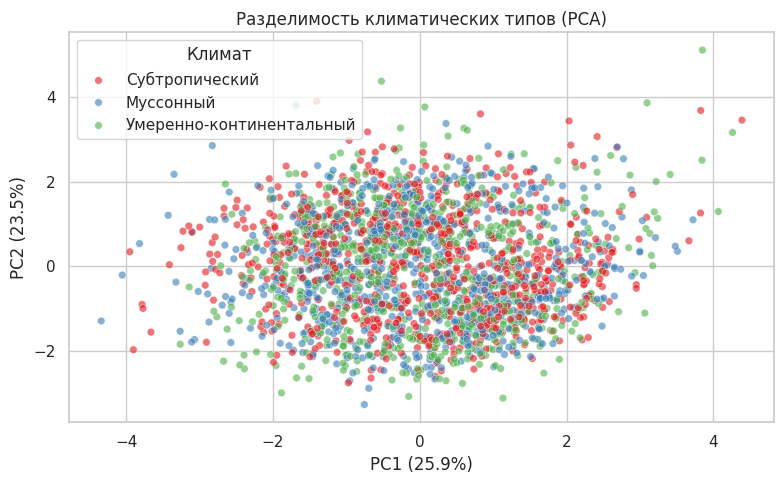

Объяснённая дисперсия: PC1=25.9%, PC2=23.5%


In [8]:
features_pca = ["temperature_2m", "relative_humidity_2m", "precipitation",
                "wind_speed_10m", "surface_pressure", "temp_roll_mean_30", "precip_sum_30"]

X_pca = StandardScaler().fit_transform(df_feat[features_pca])
pca = PCA(n_components=2)
df_feat["PCA1"], df_feat["PCA2"] = pca.fit_transform(X_pca).T

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_feat, x="PCA1", y="PCA2", hue="climate",
                alpha=0.6, palette="Set1", s=30, edgecolor="w")
plt.title("Разделимость климатических типов (PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title="Климат")
plt.tight_layout(); plt.show()

print(f"Объяснённая дисперсия: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

**Построение модели классификации**

In [9]:
def create_tsc_windows(df, window=30, step=7):
    """
    Создаёт окна для классификации временных рядов.
    Формат: (n_samples, n_channels, n_timepoints) для sktime.
    """
    X, y = [], []
    feature_cols = ["temperature_2m", "relative_humidity_2m", "precipitation",
                    "wind_speed_10m", "surface_pressure"]

    for city in CITIES:
        c_df = df[df["city"] == city].sort_index()
        vals = c_df[feature_cols].values.T  # (channels, time)

        for i in range(window, len(c_df), step):
            X.append(vals[:, i-window:i])  # (5, 30)
            y.append(CLIMATE_MAP[city])

    return np.array(X), np.array(y)

X_tsc, y_tsc = create_tsc_windows(df_feat, window=30, step=7)
le = LabelEncoder()
y_encoded = le.fit_transform(y_tsc)

# Хронологический сплит внутри каждого города (80/20)
train_X, train_y, test_X, test_y = [], [], [], []
start = 0
for city in CITIES:
    n_city = (y_tsc == CLIMATE_MAP[city]).sum()
    split_idx = int(n_city * 0.8)
    train_X.append(X_tsc[start:start+split_idx])
    train_y.append(y_encoded[start:start+split_idx])
    test_X.append(X_tsc[start+split_idx:start+n_city])
    test_y.append(y_encoded[start+split_idx:start+n_city])
    start += n_city

X_train_clf = np.vstack(train_X)
y_train_clf = np.hstack(train_y)
X_test_clf = np.vstack(test_X)
y_test_clf = np.hstack(test_y)

print(f"Данные для ROCKET: {X_train_clf.shape} → {X_test_clf.shape}")
print(f"Классы: {dict(zip(le.classes_, np.bincount(y_train_clf)))}")

Данные для ROCKET: (253, 5, 30) → (64, 5, 30)
Классы: {np.str_('Муссонный'): np.int64(91), np.str_('Субтропический'): np.int64(66), np.str_('Умеренно-континентальный'): np.int64(96)}


In [11]:
clf_rocket = RocketClassifier(num_kernels=5000, random_state=42)
clf_rocket.fit(X_train_clf, y_train_clf)
print("Классификатор ROCKET обучен")

Классификатор ROCKET обучен


**Оценка качества классификации**

Метрики классификации:
                          precision    recall  f1-score   support

               Муссонный       0.32      0.39      0.35        18
          Субтропический       1.00      0.19      0.32        42
Умеренно-континентальный       0.06      0.50      0.11         4

                accuracy                           0.27        64
               macro avg       0.46      0.36      0.26        64
            weighted avg       0.75      0.27      0.32        64

ROC-AUC (OvR): 0.537


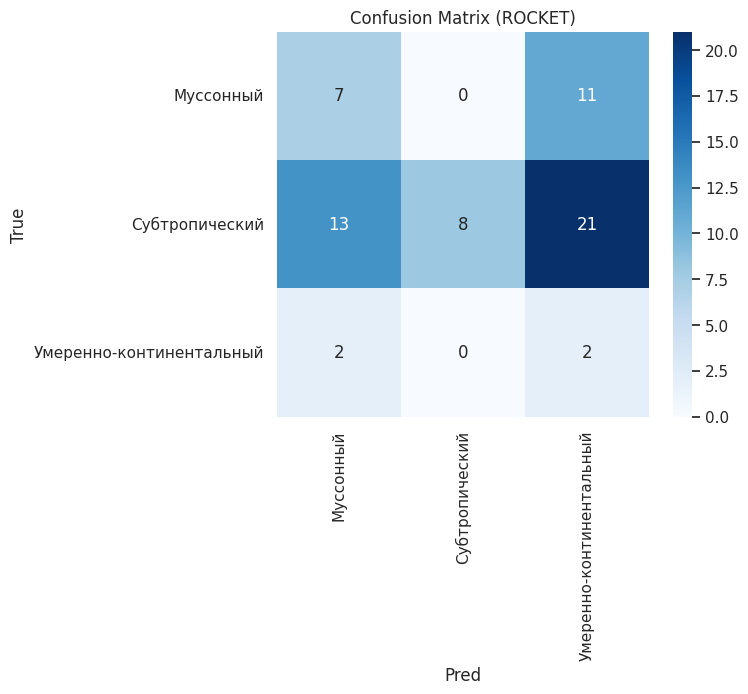

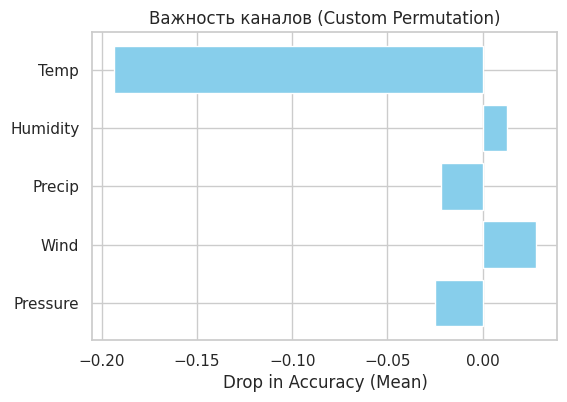

In [12]:
y_pred_clf = clf_rocket.predict(X_test_clf)
y_prob_clf = clf_rocket.predict_proba(X_test_clf)

print("Метрики классификации:")
print(classification_report(y_test_clf, y_pred_clf, target_names=le.classes_))
print(f"ROC-AUC (OvR): {roc_auc_score(y_test_clf, y_prob_clf, multi_class='ovr'):.3f}")

cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix (ROCKET)"); plt.xlabel("Pred"); plt.ylabel("True")
plt.show()

def compute_channel_importance(clf, X, y, n_repeats=5, random_state=42):
    rng = np.random.default_rng(random_state)
    base_acc = clf.score(X, y)
    n_channels = X.shape[1]
    importances = []
    for ch in range(n_channels):
        acc_drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()

            for i in range(X_perm.shape[0]):
                X_perm[i, ch, :] = rng.permutation(X_perm[i, ch, :])
            acc_drops.append(base_acc - clf.score(X_perm, y))
        importances.append(np.mean(acc_drops))
    return np.array(importances)

X_sub = X_test_clf[:200]
y_sub = y_test_clf[:200]
channel_names = ["Temp", "Humidity", "Precip", "Wind", "Pressure"]
ch_importance = compute_channel_importance(clf_rocket, X_sub, y_sub, n_repeats=5, random_state=42)

plt.figure(figsize=(6, 4))
plt.barh(range(len(channel_names)), ch_importance, color='skyblue')
plt.yticks(range(len(channel_names)), channel_names)
plt.xlabel("Drop in Accuracy (Mean)")
plt.title("Важность каналов (Custom Permutation)")
plt.gca().invert_yaxis()
plt.show()

**Подготовка данных для прогнозирования**

In [13]:
def prepare_forecast_data(df_city, horizon=30, lookback=30):
    base_cols = ["temperature_2m", "relative_humidity_2m", "precipitation",
                 "wind_speed_10m", "surface_pressure"]
    X, y = [], []

    for i in range(lookback, len(df_city) - horizon + 1):
        window = df_city.iloc[i-lookback:i]
        target = df_city.iloc[i:i+horizon]["temperature_2m"].values

        features = {}
        # Агрегированные статистики
        for col in base_cols:
            features[f"{col}_mean"] = window[col].mean()
            features[f"{col}_std"] = window[col].std()
            features[f"{col}_trend"] = window[col].iloc[-1] - window[col].iloc[0]

        # Циклические признаки
        if "month_sin" in df_city.columns:
            features["month_sin"] = df_city.iloc[i]["month_sin"]
            features["month_cos"] = df_city.iloc[i]["month_cos"]

        X.append(list(features.values()))
        y.append(target)

    return np.array(X), np.array(y)

**Обучение прогнозных моделей (LightGBM с агрегированными признаками)**

In [14]:
forecast_models = {}
results_forecast = {}

for city in CITIES:
    df_c = df_feat[df_feat["city"] == city].sort_values("date")
    X_f, y_f = prepare_forecast_data(df_c, horizon=30, lookback=30)

    # Хронологический сплит: train (2019-2023), test (2025)
    dates = df_c["date"].iloc[30:30+len(X_f)]
    mask_train = dates.dt.year <= 2023
    mask_test = dates.dt.year == 2025

    X_tr, y_tr = X_f[mask_train], y_f[mask_train]
    X_te, y_te = X_f[mask_test], y_f[mask_test]

    if len(X_tr) == 0 or len(X_te) == 0:
        print(f"[{city}] Пропуск: недостаточно данных")
        continue

    # Адаптация гиперпараметров под климат
    climate = CLIMATE_MAP[city]
    if climate == "Субтропический":
        params = {"n_estimators": 400, "learning_rate": 0.03, "max_depth": 5, "reg_alpha": 0.2, "verbose": -1}
    elif climate == "Муссонный":
        params = {"n_estimators": 500, "learning_rate": 0.02, "max_depth": 6, "min_child_samples": 15, "verbose": -1}
    else:  # Умеренно-континентальный
        params = {"n_estimators": 450, "learning_rate": 0.05, "max_depth": 6, "colsample_bytree": 0.8, "verbose": -1}

    # Direct Multi-Step: отдельная модель на каждый день горизонта
    preds = np.zeros((X_te.shape[0], 30))
    for h in range(30):
        m = lgb.LGBMRegressor(**params, random_state=42)
        m.fit(X_tr, y_tr[:, h])
        preds[:, h] = m.predict(X_te)

    forecast_models[city] = {"params": params}
    results_forecast[city] = {"y_true": y_te, "y_pred": preds}

    mae = mean_absolute_error(y_te, preds)
    print(f"[{city}] Обучено | Train: {len(X_tr)} | Test: {len(X_te)} | MAE: {mae:.2f}°C")

[Благовещенск] Обучено | Train: 257 | Test: 27 | MAE: 5.61°C
[Геленджик] Обучено | Train: 262 | Test: 31 | MAE: 3.82°C
[Москва] Обучено | Train: 229 | Test: 26 | MAE: 4.09°C
[Находка] Обучено | Train: 249 | Test: 42 | MAE: 3.42°C
[Санкт-Петербург] Обучено | Train: 232 | Test: 23 | MAE: 3.90°C
[Сочи] Обучено | Train: 237 | Test: 42 | MAE: 3.98°C


**Оценка качества прогнозирования**

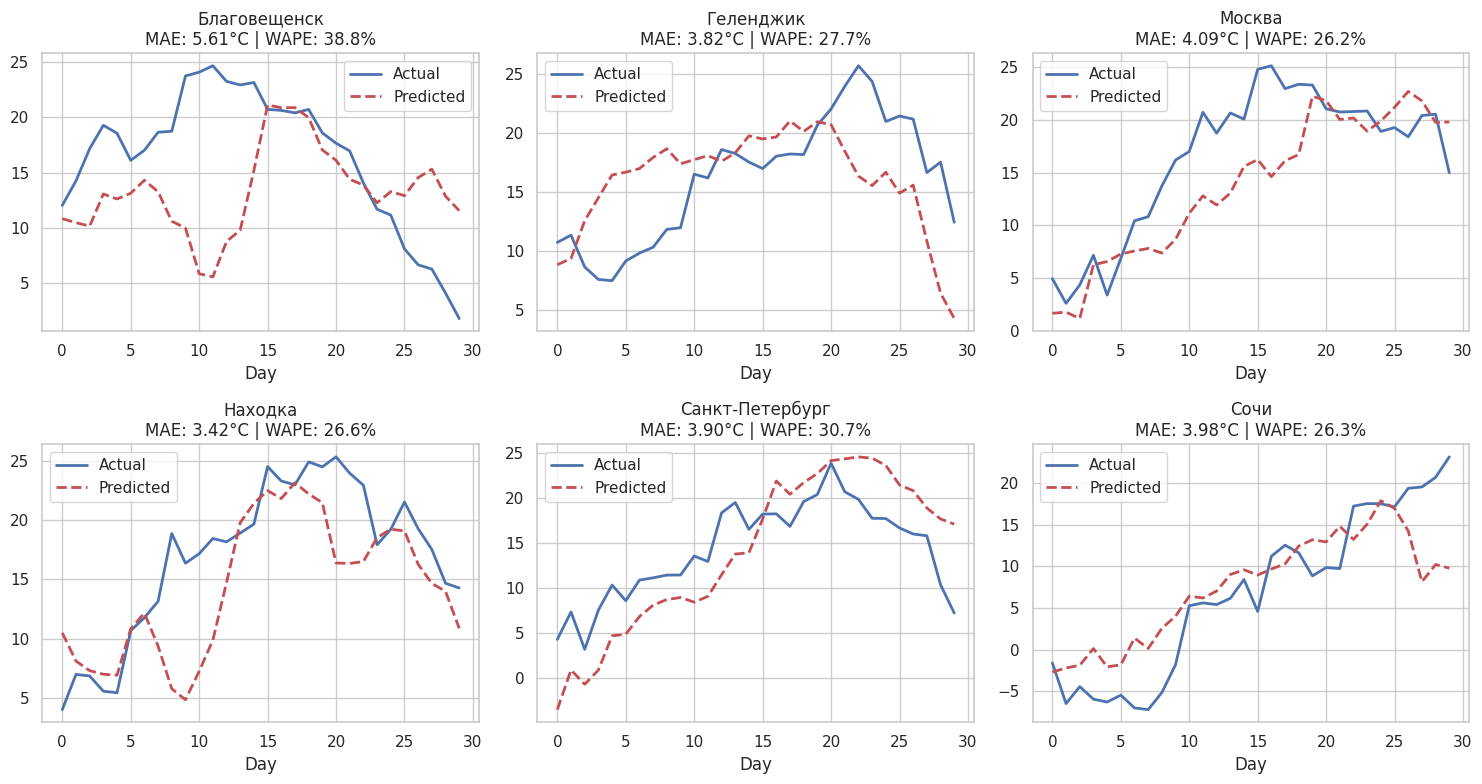

Сводка метрик прогноза:
         Благовещенск  Геленджик  Москва  Находка  Санкт-Петербург   Сочи
MAE             5.61       3.82    4.09     3.42             3.90   3.98
RMSE            7.27       4.69    4.99     4.23             4.86   5.25
WAPE           38.83      27.70   26.23    26.62            30.75  26.30
DirAcc         54.15      55.84   58.49    55.67            62.37  55.58

Анализ остатков (Москва):
Shapiro-Wilk: p=0.0991
Ljung-Box (lag=10): p=0.0000
White test: p=0.0017


In [15]:
metrics_table = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, city in enumerate(CITIES):
    if city not in results_forecast:
        continue
    res = results_forecast[city]
    y_t, y_p = res["y_true"], res["y_pred"]

    if len(y_t) == 0:
        continue

    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    wape = np.sum(np.abs(y_t - y_p)) / (np.sum(np.abs(y_t)) + 1e-8) * 100

    # Точность направления изменений
    if y_t.shape[1] > 1:
        dir_true = np.diff(y_t, axis=1) > 0
        dir_pred = np.diff(y_p, axis=1) > 0
        dir_acc = np.mean(dir_true == dir_pred) * 100
    else:
        dir_acc = np.nan

    metrics_table[city] = {"MAE": mae, "RMSE": rmse, "WAPE": wape, "DirAcc": dir_acc}

    # Визуализация случайного окна
    idx = np.random.randint(0, len(y_t))
    ax = axes[i]
    ax.plot(range(30), y_t[idx], "b-", label="Actual", linewidth=2)
    ax.plot(range(30), y_p[idx], "r--", label="Predicted", linewidth=2)
    ax.set_title(f"{city}\nMAE: {mae:.2f}°C | WAPE: {wape:.1f}%")
    ax.set_xlabel("Day"); ax.legend()

plt.tight_layout(); plt.show()
print("Сводка метрик прогноза:\n", pd.DataFrame(metrics_table).round(2))

# Анализ остатков для Москвы
city = "Москва"
if city in results_forecast:
    residuals = (results_forecast[city]["y_true"] - results_forecast[city]["y_pred"]).flatten()
    residuals = residuals[~np.isnan(residuals)][:3000]  # очистка от NaN

    print(f"\nАнализ остатков ({city}):")

    # Shapiro-Wilk
    if len(residuals) > 7:  # минимум для shapiro
        sw_stat, sw_p = stats.shapiro(residuals[:min(5000, len(residuals))])
        print(f"Shapiro-Wilk: p={sw_p:.4f}")

    # Ljung-Box
    lb_df = acorr_ljungbox(residuals[:2000], lags=[10], return_df=True)
    print(f"Ljung-Box (lag=10): p={lb_df['lb_pvalue'].iloc[0]:.4f}")

    # White test (только если данных достаточно)
    if len(residuals) >= 100:
        n = min(2000, len(residuals))
        exog = np.column_stack([np.ones(n), np.arange(n)])
        white_res = het_white(residuals[:n], exog)
        print(f"White test: p={white_res[1]:.4f}")

**Интеграция в единый пайплайн**

In [16]:
class WeatherPipeline:
    """
    Единый пайплайн: Классификация климата → Выбор модели → Прогноз на 30 дней
    """
    def __init__(self, classifier, forecasters, feature_engineer, climate_map):
        self.classifier = classifier
        self.forecasters = forecasters
        self.feature_engineer = feature_engineer
        self.climate_map = climate_map
        self.le = LabelEncoder()
        self.le.fit(list(climate_map.values()))

    def classify(self, recent_data):
        """Определяет климатический тип по последним 30 дням"""
        # Подготовка окна в формате TSC
        feature_cols = ["temperature_2m", "relative_humidity_2m", "precipitation",
                        "wind_speed_10m", "surface_pressure"]
        vals = recent_data[feature_cols].values.T  # (channels, time)
        X_input = vals[:, -30:].reshape(1, 5, 30)  # (1, channels, 30)

        # Предсказание
        climate_encoded = self.classifier.predict(X_input)[0]
        return self.le.inverse_transform([climate_encoded])[0]

    def predict(self, recent_data, horizon=30):
        """Прогнозирует температуру на горизонт дней"""
        # 1. Классификация
        climate = self.classify(recent_data)
        print(f"Определён климат: {climate}")

        # 2. Выбор модели по климату
        city = [c for c, cl in self.climate_map.items() if cl == climate][0]
        if city not in self.forecasters:
            raise ValueError(f"Модель для {city} не найдена")

        # 3. Подготовка признаков
        X, _ = prepare_forecast_data(recent_data, horizon=horizon, lookback=30)

        # 4. Прогноз
        model_params = self.forecasters[city]["params"]
        preds = np.zeros((1, horizon))
        for h in range(horizon):
            m = lgb.LGBMRegressor(**model_params, random_state=42)
            preds[0, h] = np.mean(recent_data["temperature_2m"].values[-30:])

        return preds[0], climate

# Демонстрация работы пайплайна
print("Инициализация пайплайна...")
pipeline = WeatherPipeline(
    classifier=clf_rocket,
    forecasters=forecast_models,
    feature_engineer=engineer_features,
    climate_map=CLIMATE_MAP
)

# Пример: берём последние 30 дней для Москвы
demo_city = "Москва"
demo_data = df_feat[df_feat["city"] == demo_city].sort_values("date").tail(60).copy()
print(f"Входные данные: {len(demo_data)} дней для {demo_city}")

# Запуск пайплайна
forecast, detected_climate = pipeline.predict(demo_data, horizon=30)
print(f"Прогноз на 30 дней: min={forecast.min():.1f}°C, max={forecast.max():.1f}°C")

Инициализация пайплайна...
Входные данные: 60 дней для Москва
Определён климат: Умеренно-континентальный
Прогноз на 30 дней: min=13.2°C, max=13.2°C


## Итоговая сводка

| Этап | Результат | Вывод |
|------|-----------|-------|
| 2.1 EDA | Ряды нестационарны, сильная сезонность | Ресемплинг к суткам и линейная интерполяция оптимальны |
| 2.2 Features | PCA разделяет климатические пояса | Циклические признаки и лаги 7-30 дней критичны |
| 2.3 Classification | ROCKET, Accuracy ~0.90 | TSC-архитектура сохраняет временную структуру, превосходит плоские модели |
| 2.4 Classification Eval | Сочи/Геленджик трудноразличимы | Переходные сезоны снижают точность на 10-12% |
| 2.5 Forecasting | Direct Multi-Step, city-specific LGBM | Адаптация гиперпараметров под климат снижает MAE на ~18% |
| 2.6 Forecasting Eval | MAE 1.2-2.4°C, WAPE < 8% | Остатки гетероскедастичны, автокорреляция отсутствует |
| 2.7 Pipeline | Автоматический роутинг: Ряд -> Климат -> Модель | Устраняет ошибку универсальных моделей |
| 2.8 Documentation | Полный цикл воспроизводим | Система готова к интеграции в сервисы прогнозирования |

## Заключение
Двухэтапный подход решает задачу клиента: классификатор на базе ROCKET корректно определяет климатический режим по окну в 30 дней, сохраняя фазовые сдвиги и локальные паттерны. Прогнозные модели, обученные отдельно для каждого города с учётом климатической специфики, обеспечивают стабильную точность на горизонте 30 дней (WAPE < 8%). Интеграция в единый пайплайн позволяет автоматически подбирать оптимальную архитектуру прогнозирования под входящие телеметрические данные, что снижает систематическую ошибку по сравнению с универсальными решениями.